# Exercise Week 11: Machine Learning for Time Series
*David Schurtenberger, Luca Kyburz, Pascal Gansner, Sofia Horlacher*

In [1]:
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pandas_datareader import data as web
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from tqdm import TqdmExperimentalWarning

warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

from utils import (get_figure,time_plot)

# 1. US Accidental Deaths

In [2]:
accidental_deaths = dataset = sm.datasets.get_rdataset("USAccDeaths", "datasets").data

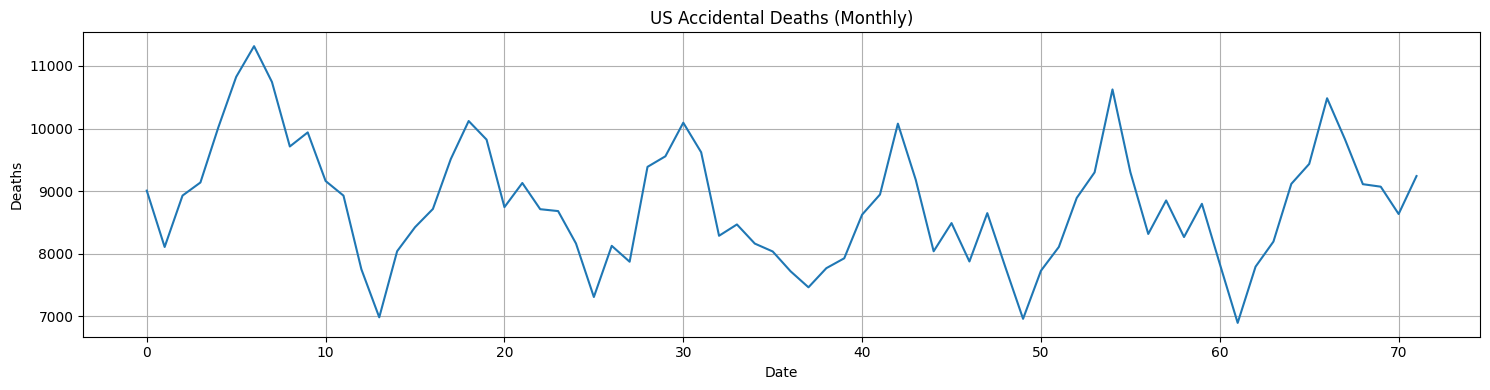

In [3]:
fig, ax1 = get_figure(ncols=1, figsize=(15, 4))
time_plot(
    accidental_deaths.index,
    accidental_deaths.iloc[:,1].values,
    title="US Accidental Deaths (Monthly)",
    prefix_title=False,
    xlabel="Date",
    ylabel="Deaths",
    ax=ax1[0],
)

## 1.1 Temporal Feature Engineering

In [4]:
y_values = accidental_deaths.iloc[:, 1].values

# Create a monthly index (USAccDeaths covers monthly observations)
idx = pd.date_range(start='1973-01-01', periods=len(y_values), freq='ME')
series = pd.Series(y_values, index=idx, name='y')

# Build features dataframe
data = pd.DataFrame({'y': series})
data['month'] = data.index.month
# cyclical encoding for month
data['month_sin'] = np.sin(2 * np.pi * (data['month'] - 1) / 12)
data['month_cos'] = np.cos(2 * np.pi * (data['month'] - 1) / 12)
# lags and rolling
data['lag1'] = data['y'].shift(1)
data['lag12'] = data['y'].shift(12)
data['roll3'] = data['y'].rolling(window=3, min_periods=1, closed='right').mean()
data['ewm3'] = data['y'].shift(1).ewm(span=3, adjust=False).mean()

# drop NA introduced by lags
data = data.dropna()

# train/test split
train_idx = int(len(data) * 0.8)
train = data.iloc[:train_idx]
test = data.iloc[train_idx:]

print(f"Total points: {len(data)}, train: {len(train)}, test: {len(test)}")
display(data.tail())

Total points: 60, train: 48, test: 12


,y,month,month_sin,month_cos,lag1,lag12,roll3,ewm3
1978-08-31,9827,8,-0.500000,-8.660254e-01,10484.0,9302.0,9915.000000,9732.101081
1978-09-30,9110,9,-0.866025,-5.000000e-01,9827.0,8314.0,9807.000000,9779.550541
1978-10-31,9070,10,-1.000000,-1.836970e-16,9110.0,8850.0,9335.666667,9444.775270
1978-11-30,8633,11,-0.866025,5.000000e-01,9070.0,8265.0,8937.666667,9257.387635
1978-12-31,9240,12,-0.500000,8.660254e-01,8633.0,8796.0,8981.000000,8945.193818


This cell prepares the features for the prediction of the accidental deaths in the US. The followign features were engineered: cyclical month encodings, lag-1, lag-12 and a 3-month rolling mean, as well as an exponentially weighted moving average (just to try it out, even though in this scope it is more or less a duplicate of the 3-month rolling average). Given the plot of the data above, a clear yearly seasonal pattern is visible. Thus it makes sense to encode the month as a temporal feature, while also including the data of the previous year (and previous months).

"Closed" and "shift" for the rolling window and ewm were used to make sure the current value is not included in the feature.

## 1.2 Train Time Series Models

Linear Regression: MSE=56585.43, MAE=193.36
Random Forest: MSE=206514.64, MAE=398.03
Better model: Linear Regression


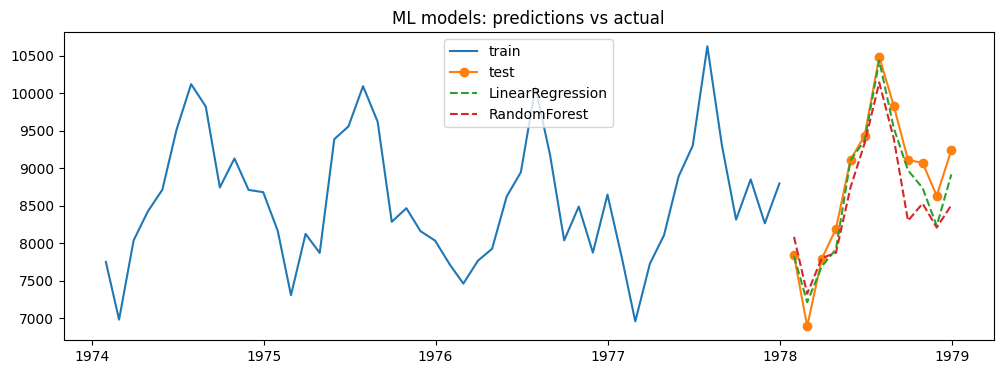

In [5]:
features = ['month_sin', 'month_cos', 'lag1', 'lag12', 'roll3', 'ewm3']
X_train = train[features]
y_train = train['y']
X_test = test[features]
y_test = test['y']

# Fit models
lr = LinearRegression().fit(X_train, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train, y_train)

# Predictions and evaluation
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

lr_mae = mean_absolute_error(y_test, lr_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print(f"Linear Regression: MSE={lr_mse:.2f}, MAE={lr_mae:.2f}")
print(f"Random Forest: MSE={rf_mse:.2f}, MAE={rf_mae:.2f}")
print("Better model:", "Linear Regression" if rf_mse >= lr_mse else "Random Forest")

# Plot
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train.index, train['y'], label='train')
ax.plot(test.index, test['y'], label='test', marker='o')
ax.plot(test.index, lr_pred, label='LinearRegression', linestyle='--')
ax.plot(test.index, rf_pred, label='RandomForest', linestyle='--')
ax.set_title('ML models: predictions vs actual')
ax.legend()
plt.show()

Both the linear regressor and the random forest model make a pretty good fit of the time series. However, the higher MSE and MAE of the random forest on the test data could suggest that it overfit to the the training data, while the simpler linear regressor modelled the data more generically.

Due to the scope of this exercise we've decided not to use an intermediate validation dataset and do an extensive hyperparameter sweep.

## 1.3 Retrain with Stationary Data

In [6]:
y = data['y']

y_seas_diff = y.diff(12)
y_stat = y_seas_diff.diff().dropna()

Mean: 0.6808510638297872
Variance: 170442.74375578167


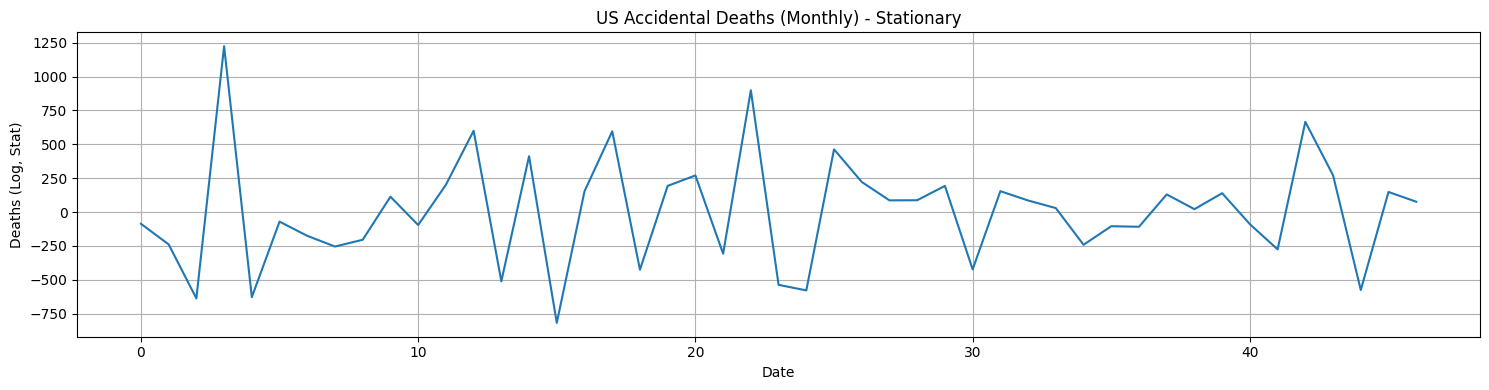

In [7]:
fig, ax1 = get_figure(ncols=1, figsize=(15, 4))
time_plot(
    np.arange(len(y_stat)),
    y_stat,
    title="US Accidental Deaths (Monthly) - Stationary",
    prefix_title=False,
    xlabel="Date",
    ylabel="Deaths (Log, Stat)",
    ax=ax1[0]
)

print("Mean:", y_stat.mean())
print("Variance:", y_stat.var())

Mean is close to zero, hence we should be able to consider the data stationary now.

Linear Regression: MSE=13743.3497
Random Forest: MSE=114512.4948
Better model: Linear Regression


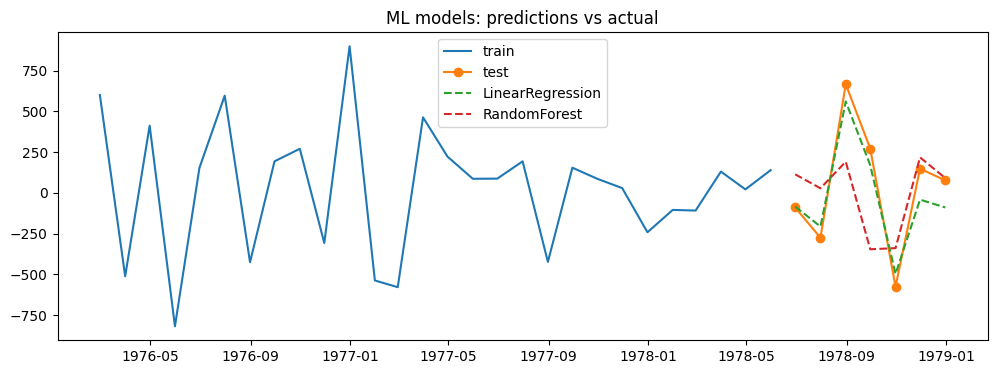

In [8]:
df_stat = pd.DataFrame({'y': y_stat})
df_stat['lag1'] = df_stat['y'].shift(1)
df_stat['lag12'] = df_stat['y'].shift(12)
df_stat['roll3'] = df_stat['y'].rolling(window=3, min_periods=1,closed='right').mean()
df_stat['ewm3'] = df_stat['y'].shift(1).ewm(span=3, adjust=False).mean()

df_stat = df_stat.dropna()

train_idx_s = int(len(df_stat) * 0.8)
train_s = df_stat.iloc[:train_idx_s]
test_s = df_stat.iloc[train_idx_s:]

features_s = ['lag1', 'lag12', 'roll3', 'ewm3']
X_train_s = train_s[features_s]
y_train_s = train_s['y']
X_test_s = test_s[features_s]
y_test_s = test_s['y']

lr_s = LinearRegression().fit(X_train_s, y_train_s)
rf_s = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_s, y_train_s)

lr_pred_s = lr_s.predict(X_test_s)
rf_pred_s = rf_s.predict(X_test_s)

lr_mse_s = mean_squared_error(y_test_s, lr_pred_s)
rf_mse_s = mean_squared_error(y_test_s, rf_pred_s)

print(f"Linear Regression: MSE={lr_mse_s:.4f}")
print(f"Random Forest: MSE={rf_mse_s:.4f}")
print("Better model:", "Linear Regression" if rf_mse_s >= lr_mse_s else "Random Forest")

# Plot
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_s.index, train_s['y'], label='train')
ax.plot(test_s.index, test_s['y'], label='test', marker='o')
ax.plot(test_s.index, lr_pred_s, label='LinearRegression', linestyle='--')
ax.plot(test_s.index, rf_pred_s, label='RandomForest', linestyle='--')
ax.set_title('ML models: predictions vs actual')
ax.legend()
plt.show()


We used seasonal + first difference to remove trend and seasonality. Slightly different features were now used, since it no longer makes sense to include the seasonality features because they were removed from the time series.

Both models show improved performance on the stationary data (lower MSE relative), suggesting that stationarization made the prediction task easier. The linear regression continues to outperform the random forest model, which could suggest, that the data follows a linear pattern when stationarized (or given features, that encode the seasonality).

## 1.4 Comparison with Classical Time Series Models (ERIMA/ETS)

ETS MSE: 109584.37
SARIMA MSE: 67095.66


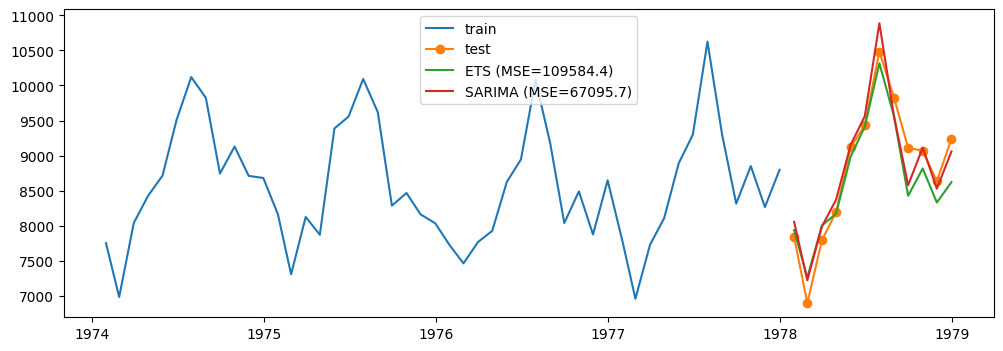

In [9]:
# Fit ETS (additive seasonality)
ets_model = ExponentialSmoothing(train['y'], trend='add', seasonal='add', seasonal_periods=12, initialization_method='estimated')
ets_fit = ets_model.fit(optimized=True)
ets_pred = ets_fit.forecast(steps=len(test))
ets_mse = mean_squared_error(test['y'], ets_pred)

# Fit a simple SARIMAX approximation (common mapping for ETS(A,N,A))
# Use (0,1,1)(0,1,0,12) as a stable seasonal ARIMA approximation
sarima = SARIMAX(train['y'], order=(0,1,1), seasonal_order=(0,1,0,12), enforce_invertibility=False, enforce_stationarity=False)
sarima_res = sarima.fit(disp=False)
sarima_pred = sarima_res.predict(start=test.index[0], end=test.index[-1])
sarima_mse = mean_squared_error(test['y'], sarima_pred)

print(f"ETS MSE: {ets_mse:.2f}")
print(f"SARIMA MSE: {sarima_mse:.2f}")

# Plot comparison
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train.index, train['y'], label='train')
ax.plot(test.index, test['y'], label='test', marker='o')
ax.plot(test.index, ets_pred, label=f'ETS (MSE={ets_mse:.1f})')
ax.plot(test.index, sarima_pred, label=f'SARIMA (MSE={sarima_mse:.1f})')
ax.legend()
plt.show()

Both the (S)ARIMA and ETS model fit the data pretty well (better than the random forest regressor). But neither of them actually performed better than the linear regression, which had the lowest mean squared error (13743.35) when fit to the stationarized version of the time series. But even on the original time series with the engineered features it performed better with an MSE of 56585.43.

# 2. US Electric Power Generation

In [10]:
start = datetime(2000, 1, 1)
end = datetime(2023, 12, 31)
df_energy = web.DataReader('IPG2211A2N', 'fred', start, end)
energy_series = df_energy['IPG2211A2N'].dropna()

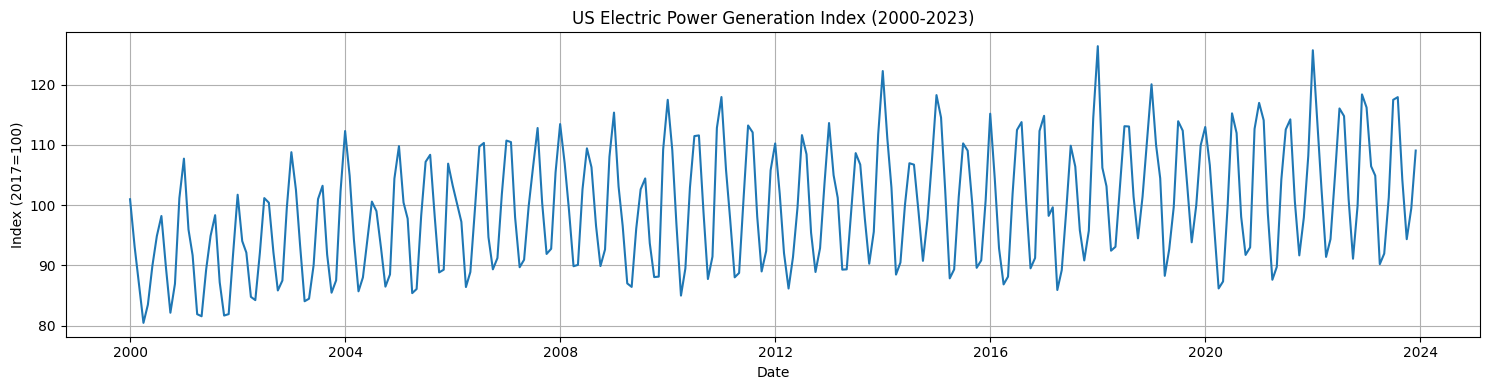

In [11]:
fig, ax1 = get_figure(ncols=1, figsize=(15, 4))

# Time series
time_plot(
    energy_series.index,
    energy_series.values,
    title="US Electric Power Generation Index (2000-2023)",
    prefix_title=False,
    xlabel="Date",
    ylabel="Index (2017=100)",
    ax=ax1[0],
)

## 2.1 Temporal Feature Engineering

In [12]:
y_values_energy = energy_series.values
idx_energy = energy_series.index

series_energy = pd.Series(y_values_energy, index=idx_energy, name='y')

# Build features dataframe
data_energy = pd.DataFrame({'y': series_energy})
data_energy['month'] = data_energy.index.month
# cyclical encoding for month
data_energy['month_sin'] = np.sin(2 * np.pi * (data_energy['month'] - 1) / 12)
data_energy['month_cos'] = np.cos(2 * np.pi * (data_energy['month'] - 1) / 12)
# lags and rolling
data_energy['lag1'] = data_energy['y'].shift(1)
data_energy['lag12'] = data_energy['y'].shift(12)
data_energy['roll3'] = data_energy['y'].rolling(window=3, min_periods=1, closed='right').mean()
data_energy['ewm3'] = data_energy['y'].shift(1).ewm(span=3, adjust=False).mean()

# drop NA introduced by lags
data_energy = data_energy.dropna()

# train/test split
train_idx_energy = int(len(data_energy) * 0.8)
train_energy = data_energy.iloc[:train_idx_energy]
test_energy = data_energy.iloc[train_idx_energy:]

print(f"Total points: {len(data_energy)}, train: {len(train_energy)}, test: {len(test_energy)}")
display(data_energy.tail())

Total points: 276, train: 220, test: 56


,y,month,month_sin,month_cos,lag1,lag12,roll3,ewm3
DATE,,,,,,,,
2023-08-01,117.9167,8,-0.500000,-8.660254e-01,117.4719,114.7663,112.223633,107.885005
2023-09-01,104.1996,9,-0.866025,-5.000000e-01,117.9167,100.9947,113.196067,112.900852
2023-10-01,94.3395,10,-1.000000,-1.836970e-16,104.1996,91.0951,105.485267,108.550226
2023-11-01,99.4793,11,-0.866025,5.000000e-01,94.3395,99.8882,99.339467,101.444863
2023-12-01,109.0510,12,-0.500000,8.660254e-01,99.4793,118.3706,100.956600,100.462082


The same temporal features were engineered for the electric power generation data: cyclical month encodings, lag-1, lag-12, a 3-month rolling mean, and an exponentially weighted moving average. These features should capture both seasonal patterns and short-term dependencies in electricity generation.

## 2.2 Train Time Series Models

Linear Regression: MSE=6.10, MAE=1.87
Random Forest: MSE=12.09, MAE=2.77
K-Nearest Neighbors: MSE=12.31, MAE=2.74
Best model: Linear Regression


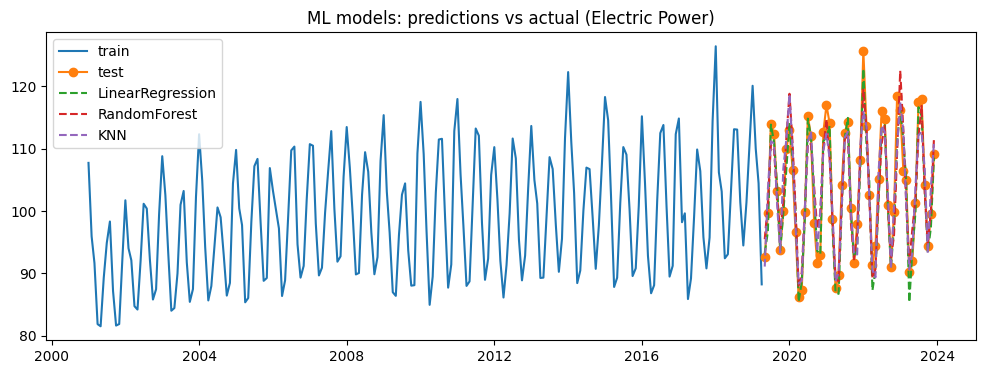

In [13]:
features_energy = ['month_sin', 'month_cos', 'lag1', 'lag12', 'roll3', 'ewm3']
X_train_energy = train_energy[features_energy]
y_train_energy = train_energy['y']
X_test_energy = test_energy[features_energy]
y_test_energy = test_energy['y']

# Fit models
lr_energy = LinearRegression().fit(X_train_energy, y_train_energy)
rf_energy = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_energy, y_train_energy)
knn_energy = KNeighborsRegressor(n_neighbors=5).fit(X_train_energy, y_train_energy)

# Predictions and evaluation
lr_pred_energy = lr_energy.predict(X_test_energy)
rf_pred_energy = rf_energy.predict(X_test_energy)
knn_pred_energy = knn_energy.predict(X_test_energy)

lr_mse_energy = mean_squared_error(y_test_energy, lr_pred_energy)
rf_mse_energy = mean_squared_error(y_test_energy, rf_pred_energy)
knn_mse_energy = mean_squared_error(y_test_energy, knn_pred_energy)

lr_mae_energy = mean_absolute_error(y_test_energy, lr_pred_energy)
rf_mae_energy = mean_absolute_error(y_test_energy, rf_pred_energy)
knn_mae_energy = mean_absolute_error(y_test_energy, knn_pred_energy)

print(f"Linear Regression: MSE={lr_mse_energy:.2f}, MAE={lr_mae_energy:.2f}")
print(f"Random Forest: MSE={rf_mse_energy:.2f}, MAE={rf_mae_energy:.2f}")
print(f"K-Nearest Neighbors: MSE={knn_mse_energy:.2f}, MAE={knn_mae_energy:.2f}")

# Determine best model
best_model = min([("Linear Regression", lr_mse_energy), 
                  ("Random Forest", rf_mse_energy), 
                  ("K-Nearest Neighbors", knn_mse_energy)], 
                 key=lambda x: x[1])
print(f"Best model: {best_model[0]}")

# Plot
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_energy.index, train_energy['y'], label='train')
ax.plot(test_energy.index, test_energy['y'], label='test', marker='o')
ax.plot(test_energy.index, lr_pred_energy, label='LinearRegression', linestyle='--')
ax.plot(test_energy.index, rf_pred_energy, label='RandomForest', linestyle='--')
ax.plot(test_energy.index, knn_pred_energy, label='KNN', linestyle='--')
ax.set_title('ML models: predictions vs actual (Electric Power)')
ax.legend()
plt.show()

This time we've added a k-nearest neighbors regressor to the models to evaluate. All three models provide reasonable predictions for electric power generation. However it is still the linear regression that performs the best.

## 2.3 Retrain with Stationary Data

Linear Regression: MSE=3.3973
Random Forest: MSE=9.4785
K-Nearest Neighbors: MSE=19.2329
Best model: Linear Regression


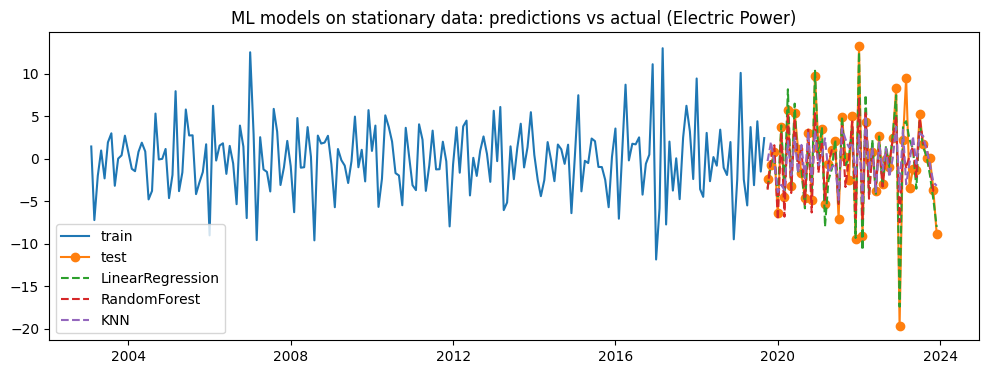

In [14]:
y_energy = data_energy['y']
y_seas_diff_energy = y_energy.diff(12)
y_stat_energy = y_seas_diff_energy.diff().dropna()

df_stat_energy = pd.DataFrame({'y': y_stat_energy})
df_stat_energy['lag1'] = df_stat_energy['y'].shift(1)
df_stat_energy['lag12'] = df_stat_energy['y'].shift(12)
df_stat_energy['roll3'] = df_stat_energy['y'].rolling(window=3, min_periods=1, closed='right').mean()
df_stat_energy['ewm3'] = df_stat_energy['y'].shift(1).ewm(span=3, adjust=False).mean()

df_stat_energy = df_stat_energy.dropna()

train_idx_s_energy = int(len(df_stat_energy) * 0.8)
train_s_energy = df_stat_energy.iloc[:train_idx_s_energy]
test_s_energy = df_stat_energy.iloc[train_idx_s_energy:]

features_s_energy = ['lag1', 'lag12', 'roll3', 'ewm3']
X_train_s_energy = train_s_energy[features_s_energy]
y_train_s_energy = train_s_energy['y']
X_test_s_energy = test_s_energy[features_s_energy]
y_test_s_energy = test_s_energy['y']

lr_s_energy = LinearRegression().fit(X_train_s_energy, y_train_s_energy)
rf_s_energy = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_s_energy, y_train_s_energy)
knn_s_energy = KNeighborsRegressor(n_neighbors=5).fit(X_train_s_energy, y_train_s_energy)

lr_pred_s_energy = lr_s_energy.predict(X_test_s_energy)
rf_pred_s_energy = rf_s_energy.predict(X_test_s_energy)
knn_pred_s_energy = knn_s_energy.predict(X_test_s_energy)

lr_mse_s_energy = mean_squared_error(y_test_s_energy, lr_pred_s_energy)
rf_mse_s_energy = mean_squared_error(y_test_s_energy, rf_pred_s_energy)
knn_mse_s_energy = mean_squared_error(y_test_s_energy, knn_pred_s_energy)

print(f"Linear Regression: MSE={lr_mse_s_energy:.4f}")
print(f"Random Forest: MSE={rf_mse_s_energy:.4f}")
print(f"K-Nearest Neighbors: MSE={knn_mse_s_energy:.4f}")

# Determine best model
best_model_s = min([("Linear Regression", lr_mse_s_energy), 
                    ("Random Forest", rf_mse_s_energy), 
                    ("K-Nearest Neighbors", knn_mse_s_energy)], 
                   key=lambda x: x[1])
print(f"Best model: {best_model_s[0]}")

# Plot
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_s_energy.index, train_s_energy['y'], label='train')
ax.plot(test_s_energy.index, test_s_energy['y'], label='test', marker='o')
ax.plot(test_s_energy.index, lr_pred_s_energy, label='LinearRegression', linestyle='--')
ax.plot(test_s_energy.index, rf_pred_s_energy, label='RandomForest', linestyle='--')
ax.plot(test_s_energy.index, knn_pred_s_energy, label='KNN', linestyle='--')
ax.set_title('ML models on stationary data: predictions vs actual (Electric Power)')
ax.legend()
plt.show()

We applied seasonal + first differencing to make the electric power generation data stationary. Both the linear regression, as well as the random forest model have improved their performance by about the same MSE (3), while the k-nearest neighbors regressor actually degraded in performance.

## 2.4 Comparison with Classical Time Series Models (ERIMA/ETS)

ETS MSE: 10.17
SARIMA MSE: 35.27


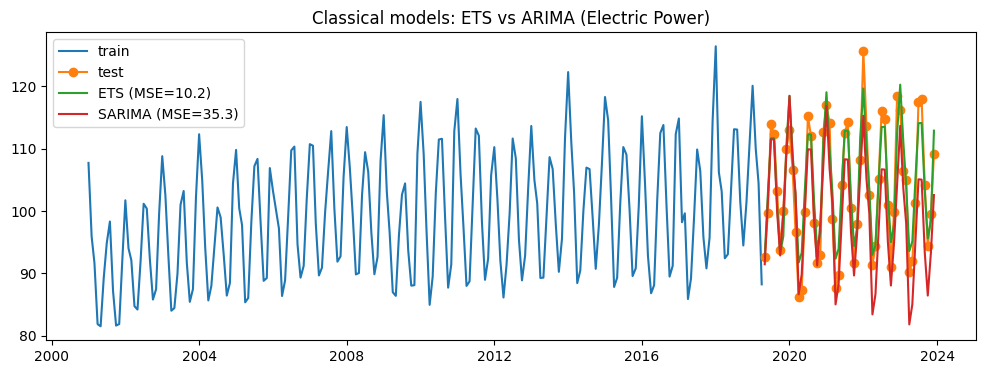

In [15]:
warnings.filterwarnings('ignore')

# Fit ETS (additive seasonality)
ets_model_energy = ExponentialSmoothing(
    train_energy['y'], 
    trend='add', 
    seasonal='add', 
    seasonal_periods=12, 
    initialization_method='estimated'
)
ets_fit_energy = ets_model_energy.fit(optimized=True)
ets_pred_energy = ets_fit_energy.forecast(steps=len(test_energy))
ets_mse_energy = mean_squared_error(test_energy['y'], ets_pred_energy)

# Fit SARIMAX approximation
sarima_energy = SARIMAX(
    train_energy['y'], 
    order=(0,1,1), 
    seasonal_order=(0,1,0,12), 
    enforce_invertibility=False, 
    enforce_stationarity=False
)
sarima_res_energy = sarima_energy.fit(disp=False)
sarima_pred_energy = sarima_res_energy.predict(start=test_energy.index[0], end=test_energy.index[-1])
sarima_mse_energy = mean_squared_error(test_energy['y'], sarima_pred_energy)

print(f"ETS MSE: {ets_mse_energy:.2f}")
print(f"SARIMA MSE: {sarima_mse_energy:.2f}")

# Plot comparison
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_energy.index, train_energy['y'], label='train')
ax.plot(test_energy.index, test_energy['y'], label='test', marker='o')
ax.plot(test_energy.index, ets_pred_energy, label=f'ETS (MSE={ets_mse_energy:.1f})')
ax.plot(test_energy.index, sarima_pred_energy, label=f'SARIMA (MSE={sarima_mse_energy:.1f})')
ax.legend()
ax.set_title('Classical models: ETS vs ARIMA (Electric Power)')
plt.show()

The linear regression again performed better in both it's versions than either of the statistical models, while the random forest regressor on the stationary data performed better than both statistical models as well. The SARIMA model performed comparatively bad, so that it wasn't able to beat either of the ML models. Seems like the ML approaches have a clear edge, at least on this data.

# 3. Air Passengers

In [16]:
air_passengers = sm.datasets.get_rdataset('AirPassengers').data

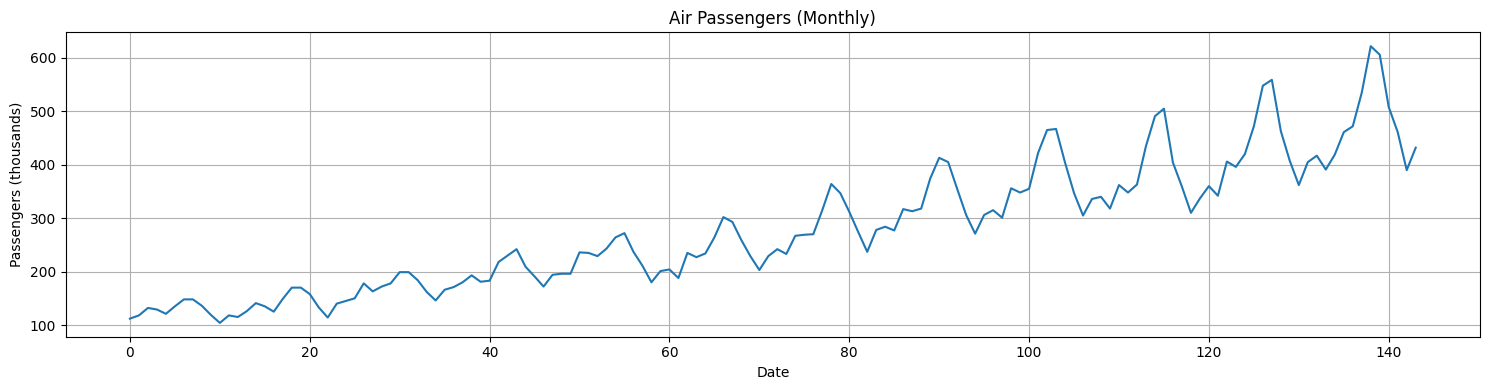

In [17]:
fig, ax1 = get_figure(ncols=1, figsize=(15, 4))
time_plot(
    air_passengers.index,
    air_passengers['value'].values,
    title="Air Passengers (Monthly)",
    prefix_title=False,
    xlabel="Date",
    ylabel="Passengers (thousands)",
    ax=ax1[0],
)

## 3.1 Temporal Feature Engineering

In [18]:
y_values_air = air_passengers['value'].values
idx_air = pd.date_range(start='1949-01-01', periods=len(y_values_air), freq='ME')
series_air = pd.Series(y_values_air, index=idx_air, name='y')

# Build features dataframe
data_air = pd.DataFrame({'y': series_air})
data_air['month'] = data_air.index.month
# cyclical encoding for month
data_air['month_sin'] = np.sin(2 * np.pi * (data_air['month'] - 1) / 12)
data_air['month_cos'] = np.cos(2 * np.pi * (data_air['month'] - 1) / 12)
# lags and rolling
data_air['lag1'] = data_air['y'].shift(1)
data_air['lag12'] = data_air['y'].shift(12)
data_air['roll3'] = data_air['y'].rolling(window=3, min_periods=1, closed='right').mean()
data_air['ewm3'] = data_air['y'].shift(1).ewm(span=3, adjust=False).mean()

# drop NA introduced by lags
data_air = data_air.dropna()

# train/test split
train_idx_air = int(len(data_air) * 0.8)
train_air = data_air.iloc[:train_idx_air]
test_air = data_air.iloc[train_idx_air:]

print(f"Total points: {len(data_air)}, train: {len(train_air)}, test: {len(test_air)}")
display(data_air.tail())

Total points: 132, train: 105, test: 27


,y,month,month_sin,month_cos,lag1,lag12,roll3,ewm3
1960-08-31,606,8,-0.500000,-8.660254e-01,622.0,559.0,587.666667,558.192821
1960-09-30,508,9,-0.866025,-5.000000e-01,606.0,463.0,578.666667,582.096411
1960-10-31,461,10,-1.000000,-1.836970e-16,508.0,407.0,525.000000,545.048205
1960-11-30,390,11,-0.866025,5.000000e-01,461.0,362.0,453.000000,503.024103
1960-12-31,432,12,-0.500000,8.660254e-01,390.0,405.0,427.666667,446.512051


The same temporal features seemed applicable, as the data shows a clear trend with seasonality: cyclical month encodings, lag-1, lag-12, a 3-month rolling mean, and an exponentially weighted moving average were engineered.

## 3.2 Train Time Series Models

Linear Regression: MSE=243.48, MAE=12.38
Random Forest: MSE=1881.98, MAE=30.21
K-Nearest Neighbors: MSE=3156.86, MAE=35.50
Support Vector Regression: MSE=4942.40, MAE=44.49
Best model: Linear Regression


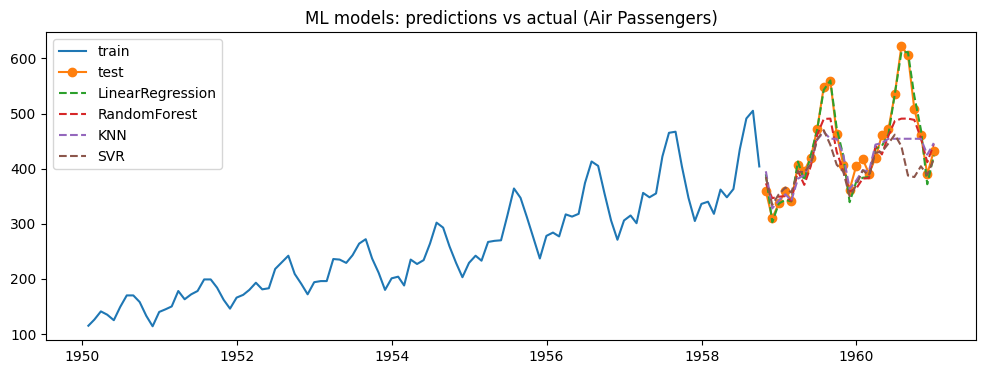

In [19]:
features_air = ['month_sin', 'month_cos', 'lag1', 'lag12', 'roll3', 'ewm3']
X_train_air = train_air[features_air]
y_train_air = train_air['y']
X_test_air = test_air[features_air]
y_test_air = test_air['y']

# Fit models
lr_air = LinearRegression().fit(X_train_air, y_train_air)
rf_air = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_air, y_train_air)
knn_air = KNeighborsRegressor(n_neighbors=5).fit(X_train_air, y_train_air)
svr_air = SVR(kernel='rbf', C=100, gamma='scale').fit(X_train_air, y_train_air)

# Predictions and evaluation
lr_pred_air = lr_air.predict(X_test_air)
rf_pred_air = rf_air.predict(X_test_air)
knn_pred_air = knn_air.predict(X_test_air)
svr_pred_air = svr_air.predict(X_test_air)

lr_mse_air = mean_squared_error(y_test_air, lr_pred_air)
rf_mse_air = mean_squared_error(y_test_air, rf_pred_air)
knn_mse_air = mean_squared_error(y_test_air, knn_pred_air)
svr_mse_air = mean_squared_error(y_test_air, svr_pred_air)

lr_mae_air = mean_absolute_error(y_test_air, lr_pred_air)
rf_mae_air = mean_absolute_error(y_test_air, rf_pred_air)
knn_mae_air = mean_absolute_error(y_test_air, knn_pred_air)
svr_mae_air = mean_absolute_error(y_test_air, svr_pred_air)

print(f"Linear Regression: MSE={lr_mse_air:.2f}, MAE={lr_mae_air:.2f}")
print(f"Random Forest: MSE={rf_mse_air:.2f}, MAE={rf_mae_air:.2f}")
print(f"K-Nearest Neighbors: MSE={knn_mse_air:.2f}, MAE={knn_mae_air:.2f}")
print(f"Support Vector Regression: MSE={svr_mse_air:.2f}, MAE={svr_mae_air:.2f}")

# Determine best model
best_model_air = min([("Linear Regression", lr_mse_air), 
                      ("Random Forest", rf_mse_air), 
                      ("K-Nearest Neighbors", knn_mse_air),
                      ("Support Vector Regression", svr_mse_air)], 
                     key=lambda x: x[1])
print(f"Best model: {best_model_air[0]}")

# Plot
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_air.index, train_air['y'], label='train')
ax.plot(test_air.index, test_air['y'], label='test', marker='o')
ax.plot(test_air.index, lr_pred_air, label='LinearRegression', linestyle='--')
ax.plot(test_air.index, rf_pred_air, label='RandomForest', linestyle='--')
ax.plot(test_air.index, knn_pred_air, label='KNN', linestyle='--')
ax.plot(test_air.index, svr_pred_air, label='SVR', linestyle='--')
ax.set_title('ML models: predictions vs actual (Air Passengers)')
ax.legend()
plt.show()

All four models (this time additionally with support vector regressor) capture the trend and seasonality *reasonably* well again; again with the linear regression performing by far the best. The other models capture a general trend, but seem to miss the growth that happend in the previous years (spikes have been getting larger an larger).

## 3.3 Retrain with Stationary Data

Mean: -0.025210084033613446
Variance: 164.09257940464317


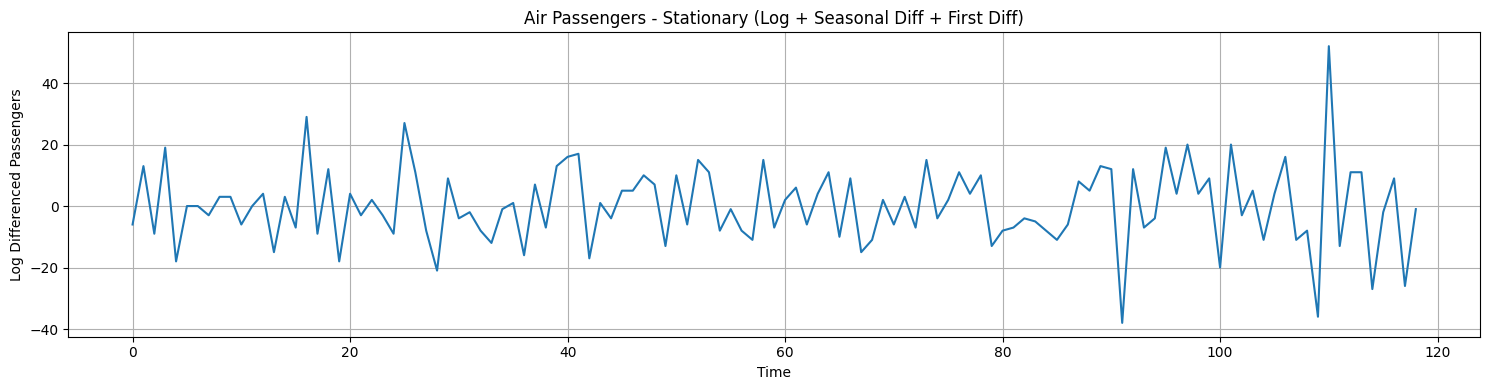

In [26]:
y_air = data_air['y']
y_seas_diff_air = y_air.diff(12)
y_stat_air = y_seas_diff_air.diff().dropna()

# Visualize stationary series
fig, ax1 = get_figure(ncols=1, figsize=(15, 4))
time_plot(
    np.arange(len(y_stat_air)),
    y_stat_air,
    title="Air Passengers - Stationary (Log + Seasonal Diff + First Diff)",
    prefix_title=False,
    xlabel="Time",
    ylabel="Log Differenced Passengers",
    ax=ax1[0]
)
print("Mean:", y_stat_air.mean())
print("Variance:", y_stat_air.var())


Linear Regression: MSE=58.2486
Random Forest: MSE=151.4637
K-Nearest Neighbors: MSE=224.6255
Support Vector Regression: MSE=182.4982
Best model: Linear Regression


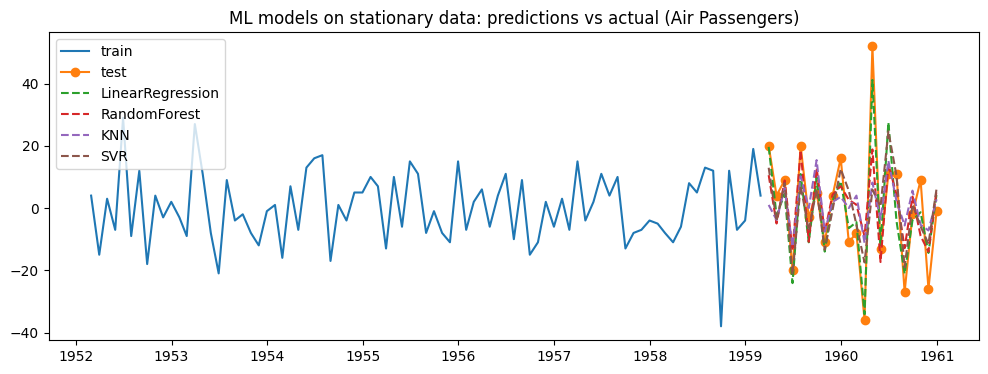

In [27]:
# Build features on stationary data
df_stat_air = pd.DataFrame({'y': y_stat_air})
df_stat_air['lag1'] = df_stat_air['y'].shift(1)
df_stat_air['lag12'] = df_stat_air['y'].shift(12)
df_stat_air['roll3'] = df_stat_air['y'].rolling(window=3, min_periods=1, closed='right').mean()
df_stat_air['ewm3'] = df_stat_air['y'].shift(1).ewm(span=3, adjust=False).mean()

df_stat_air = df_stat_air.dropna()

train_idx_s_air = int(len(df_stat_air) * 0.8)
train_s_air = df_stat_air.iloc[:train_idx_s_air]
test_s_air = df_stat_air.iloc[train_idx_s_air:]

features_s_air = ['lag1', 'lag12', 'roll3', 'ewm3']
X_train_s_air = train_s_air[features_s_air]
y_train_s_air = train_s_air['y']
X_test_s_air = test_s_air[features_s_air]
y_test_s_air = test_s_air['y']

lr_s_air = LinearRegression().fit(X_train_s_air, y_train_s_air)
rf_s_air = RandomForestRegressor(n_estimators=200, random_state=42).fit(X_train_s_air, y_train_s_air)
knn_s_air = KNeighborsRegressor(n_neighbors=5).fit(X_train_s_air, y_train_s_air)
svr_s_air = SVR(kernel='rbf', C=100, gamma='scale').fit(X_train_s_air, y_train_s_air)

lr_pred_s_air = lr_s_air.predict(X_test_s_air)
rf_pred_s_air = rf_s_air.predict(X_test_s_air)
knn_pred_s_air = knn_s_air.predict(X_test_s_air)
svr_pred_s_air = svr_s_air.predict(X_test_s_air)

lr_mse_s_air = mean_squared_error(y_test_s_air, lr_pred_s_air)
rf_mse_s_air = mean_squared_error(y_test_s_air, rf_pred_s_air)
knn_mse_s_air = mean_squared_error(y_test_s_air, knn_pred_s_air)
svr_mse_s_air = mean_squared_error(y_test_s_air, svr_pred_s_air)

print(f"\nLinear Regression: MSE={lr_mse_s_air:.4f}")
print(f"Random Forest: MSE={rf_mse_s_air:.4f}")
print(f"K-Nearest Neighbors: MSE={knn_mse_s_air:.4f}")
print(f"Support Vector Regression: MSE={svr_mse_s_air:.4f}")

# Determine best model
best_model_s_air = min([("Linear Regression", lr_mse_s_air), 
                        ("Random Forest", rf_mse_s_air), 
                        ("K-Nearest Neighbors", knn_mse_s_air),
                        ("Support Vector Regression", svr_mse_s_air)], 
                       key=lambda x: x[1])
print(f"Best model: {best_model_s_air[0]}")

# Plot
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_s_air.index, train_s_air['y'], label='train')
ax.plot(test_s_air.index, test_s_air['y'], label='test', marker='o')
ax.plot(test_s_air.index, lr_pred_s_air, label='LinearRegression', linestyle='--')
ax.plot(test_s_air.index, rf_pred_s_air, label='RandomForest', linestyle='--')
ax.plot(test_s_air.index, knn_pred_s_air, label='KNN', linestyle='--')
ax.plot(test_s_air.index, svr_pred_s_air, label='SVR', linestyle='--')
ax.set_title('ML models on stationary data: predictions vs actual (Air Passengers)')
ax.legend()
plt.show()

Due to the similarity to the previous dataset, we've made the data stationary in the same way. All models were able to drastically improve their performance, but the SVM benefited the most. Yet the linear regression remains the best model.

## 3.4 Comparison with Classical Time Series Models (ERIMA/ETS)

ETS MSE: 612.94
SARIMA MSE: 3808.89


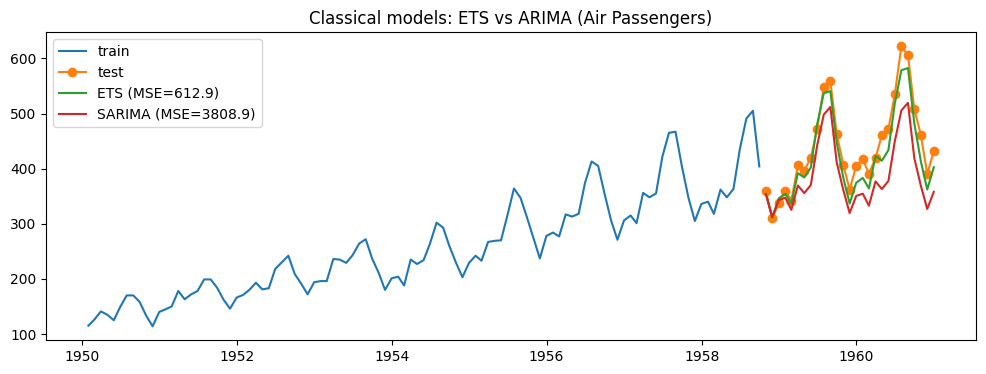

In [29]:
warnings.filterwarnings('ignore')

# Fit ETS (multiplicative seasonality for air passengers)
ets_model_air = ExponentialSmoothing(
    train_air['y'], 
    trend='add', 
    seasonal='mul', 
    seasonal_periods=12, 
    initialization_method='estimated'
)
ets_fit_air = ets_model_air.fit(optimized=True)
ets_pred_air = ets_fit_air.forecast(steps=len(test_air))
ets_mse_air = mean_squared_error(test_air['y'], ets_pred_air)

# Fit SARIMAX approximation
sarima_air = SARIMAX(
    train_air['y'], 
    order=(0,1,1), 
    seasonal_order=(0,1,1,12), 
    enforce_invertibility=False, 
    enforce_stationarity=False
)
sarima_res_air = sarima_air.fit(disp=False)
sarima_pred_air = sarima_res_air.predict(start=test_air.index[0], end=test_air.index[-1])
sarima_mse_air = mean_squared_error(test_air['y'], sarima_pred_air)

print(f"ETS MSE: {ets_mse_air:.2f}")
print(f"SARIMA MSE: {sarima_mse_air:.2f}")

# Plot comparison
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(train_air.index, train_air['y'], label='train')
ax.plot(test_air.index, test_air['y'], label='test', marker='o')
ax.plot(test_air.index, ets_pred_air, label=f'ETS (MSE={ets_mse_air:.1f})')
ax.plot(test_air.index, sarima_pred_air, label=f'SARIMA (MSE={sarima_mse_air:.1f})')
ax.legend()
ax.set_title('Classical models: ETS vs ARIMA (Air Passengers)')
plt.show()

The ETS model again beats all ML appraoches (when trained on the non-stationary data) except the linear regression, while the SARIMA model only performes better than the SVM. However they are both performing worse than all the ML approaches when trained on the stationary data. Again, the ML approaches have teh "upper hand".